## **Case Study 1: Techno-Economic Comparison of Hydrogen Production Pathways with JSON I/O files**

This section demonstrates the use of OpenPyTEA with configuration files to perform a complete techno-economic analysis, based on `Case Study 1`. In this example, different hydrogen production pathways are evaluated under a consistent set of economic assumptions, allowing direct comparison of their performance.

The workflow illustrates how equipment data, plant configurations, and analysis settings can be defined through structured input files, enabling a reproducible and scalable TEA process.

For more details on the processes and assumptions used in this case study, please refer to:
[Case Study 1 ](https://github.com/pbtamarona/OpenPyTEA/blob/main/examples/case_study_1.ipynb)

Now let's import the the functions that we need from `openpytea.io`

In [1]:
from openpytea import run_equipment, run_plant, run_tea, load_results

There are four main functions that operate on input configuration files:

- `run_equipment()` — reads the equipment configuration file and generates a list of Equipment objects, including cost estimation based on - correlations or user-defined values
- `run_plant()` — reads the plant configuration file, combines it with the equipment list, and initializes the `Plant` object with all economic and operational parameters
- `run_tea()` — executes the full techno-economic analysis workflow, including cost calculations, sensitivity analysis, and Monte Carlo simulation, based on the provided configuration files
- `run_openpytea()` — the single-file counterpart to `run_tea()`: runs the exact same workflow, but from one combined configuration file instead of three, which is convenient for CLI/automation use (demonstrated further below)

These functions enable a structured and automated workflow, allowing users to perform TEA without manually defining objects in code.

### **Equipment I/O**

First we use `run_equipment()` to read the equipment configuration file to to generate the corresponding `Equipment` objects and store the results in an output file. Now, we do this for the steam methane reforming (SMR) case for an example:

In [2]:
smr_equipment_list = run_equipment(input_path="input_configs/smr_equipment.json",
                                   output_path="outputs/smr_equipment_results.json")

You can call your `Equipment` object like this:

In [3]:
print(smr_equipment_list[1])

Name=MTR-1, Category=Motors & generators, Sub-type=Totally enclosed motor, Material=Carbon steel, Process Type=Electrical, Parameter=1050, Number of units=1, Purchased Cost=139943.48924210345, Direct Cost=461813.5144989414)


### **Plant I/O**

The `run_plant()` function is used to read the plant configuration file, combine it with the equipment configuration, and initialize a `Plant` object with all economic and operational parameters.

Again, this is demonstrated using the SMR case:

In [4]:
smr_plant = run_plant(plant_input_path="input_configs/smr_plant.json",
                      plant_output_path="outputs/smr_plant_results.json",
                      equipment_input_path="input_configs/smr_equipment.json")

### **Analysis I/O**

The `run_tea()` function is used to execute the full techno-economic analysis based on the provided equipment, plant, and analysis configuration files. It performs all calculations, including cost breakdowns, sensitivity analysis, and Monte Carlo simulation, and stores the results in structured output files along with the corresponding plots, if selected.

The following example illustrates the SMR case. We use the three configuration files—equipment, plant, and analysis—as inputs to `run_tea()`:

In [5]:
run_tea(equipment_input_path="input_configs/smr_equipment.json",
        plant_input_path="input_configs/smr_plant.json",
        analysis_input_path="input_configs/analysis-1.json",
        output_dir="outputs/smr_tea_results")

Monte Carlo: 100%|██████████| 10/10 [00:08<00:00,  1.16it/s]


{'direct_costs': {'components': [{'COMP-1': 8365089.412098588,
    'MTR-1': 461813.5144989414,
    'COMP-2': 6523301.034550522,
    'MTR-2': 252706.7363007067,
    'HX-1': 170780.61598578424,
    'HX-2': 164558.5338333728,
    'HX-3': 232182.9102927071,
    'COOLER': 267593.02420357213,
    'SMR-REACTOR': 84496.00876540283,
    'WGS-HT-REACTOR': 100738.82800271554,
    'WGS-LT-REACTOR': 294672.72624404693,
    'FURNACE': 10205409.021537386,
    'PUMP': 42067.02655540013,
    'PSA': 1979930.666979625}],
  'labels': [['COMP-1',
    'COMP-2',
    'COOLER',
    'FURNACE',
    'HX-1',
    'HX-2',
    'HX-3',
    'MTR-1',
    'MTR-2',
    'PSA',
    'PUMP',
    'SMR-REACTOR',
    'WGS-HT-REACTOR',
    'WGS-LT-REACTOR']],
  'values': [[8365089.412098588,
    6523301.034550522,
    267593.02420357213,
    10205409.021537386,
    170780.61598578424,
    164558.5338333728,
    232182.9102927071,
    461813.5144989414,
    252706.7363007067,
    1979930.666979625,
    42067.02655540013,
    84496

The `run_tea()` function returns a JSON dictionary containing equipment, plant, and analysis results. In addition, based on the analysis settings specified in the input configuration files, it generates the corresponding plots in the requested format and resolution.

You can use the `load_results()` function from `openpytea.io` to load previously saved results from the output files for further analysis or visualization.

In [6]:
smr_results = load_results(filepath="outputs/smr_tea_results/Steam Reforming_analysis_results.json")

For example, like plotting the Monte Carlo results for the levelized cost:

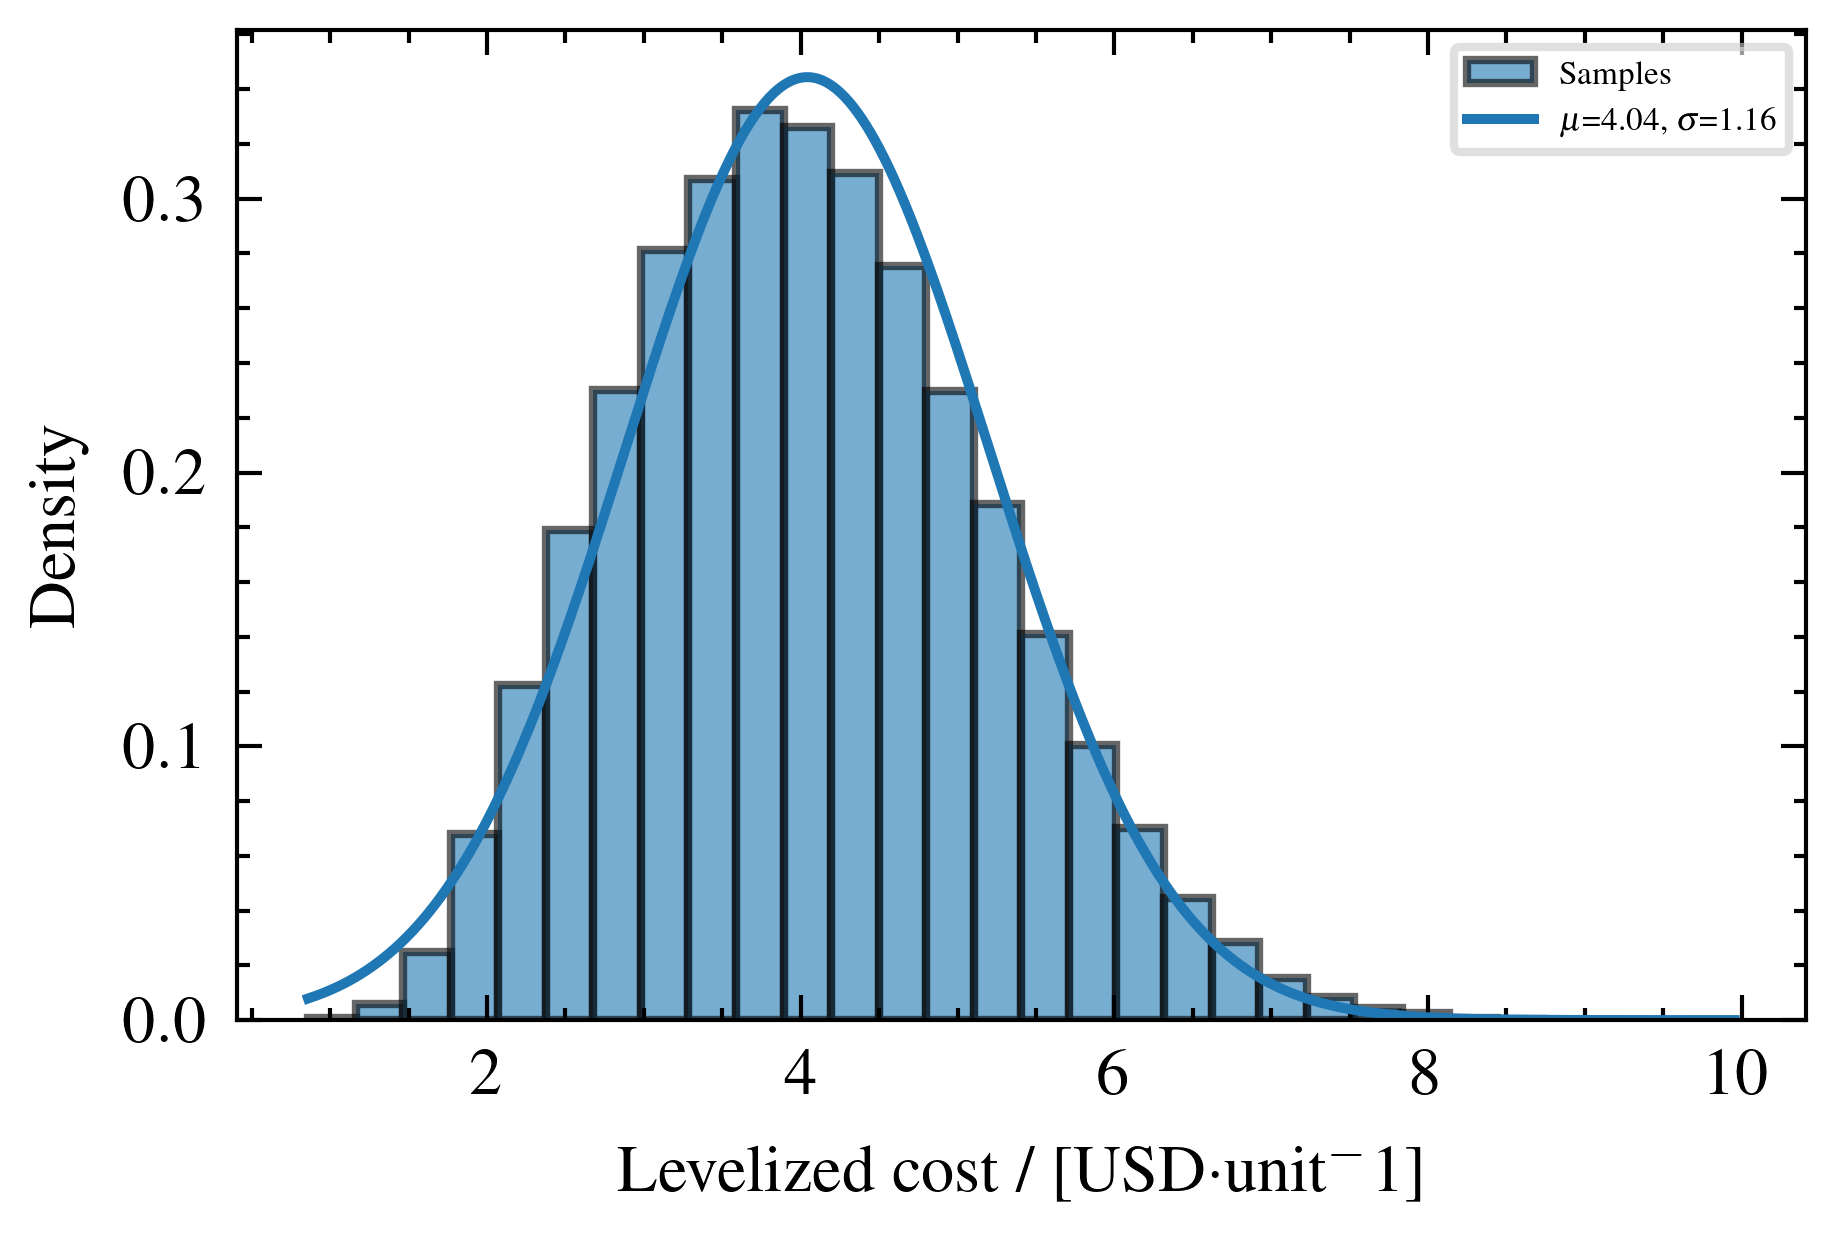

In [7]:
smr_mc = smr_results["monte_carlo"]

from openpytea.plotting import plot_monte_carlo # We import the plotting function to visualize the Monte Carlo results

fig, ax = plot_monte_carlo(smr_mc)

### **Single-File / CLI Workflow**

For a more compact, CLI-friendly workflow, `run_openpytea()` runs the exact same pipeline as `run_tea()`, but from a **single** combined JSON file instead of three. The `equipment`, `plant`, and `analysis` blocks (plus the optional `output` block) simply live under one file's top-level keys instead of being split across `equipment.json`, `plant.json`, and `analysis.json`.

This is convenient when sharing one self-contained study file, or when wiring OpenPyTEA into a CLI or automation pipeline. The example below reruns the SMR case above, but from `input_configs/smr_combined.json`, which merges `smr_equipment.json`, `smr_plant.json`, and `analysis-1.json` into a single file:

In [8]:
from openpytea import run_openpytea

run_openpytea(config_path="input_configs/smr_combined.json",
              output_dir="outputs/smr_combined_results")

Monte Carlo: 100%|██████████| 10/10 [00:13<00:00,  1.39s/it]


{'direct_costs': {'components': [{'COMP-1': 8365089.412098588,
    'MTR-1': 461813.5144989414,
    'COMP-2': 6523301.034550522,
    'MTR-2': 252706.7363007067,
    'HX-1': 170780.61598578424,
    'HX-2': 164558.5338333728,
    'HX-3': 232182.9102927071,
    'COOLER': 267593.02420357213,
    'SMR-REACTOR': 84496.00876540283,
    'WGS-HT-REACTOR': 100738.82800271554,
    'WGS-LT-REACTOR': 294672.72624404693,
    'FURNACE': 10205409.021537386,
    'PUMP': 42067.02655540013,
    'PSA': 1979930.666979625}],
  'labels': [['COMP-1',
    'COMP-2',
    'COOLER',
    'FURNACE',
    'HX-1',
    'HX-2',
    'HX-3',
    'MTR-1',
    'MTR-2',
    'PSA',
    'PUMP',
    'SMR-REACTOR',
    'WGS-HT-REACTOR',
    'WGS-LT-REACTOR']],
  'values': [[8365089.412098588,
    6523301.034550522,
    267593.02420357213,
    10205409.021537386,
    170780.61598578424,
    164558.5338333728,
    232182.9102927071,
    461813.5144989414,
    252706.7363007067,
    1979930.666979625,
    42067.02655540013,
    84496

`run_openpytea()` returns the same results dictionary and writes the same `{plant_name}_equipment_results.json`, `{plant_name}_plant_results.json`, and `{plant_name}_analysis_results.json` files (plus plots, if requested) as `run_tea()`, so `load_results()` and the rest of the workflow are unchanged:

Since `input_configs/smr_combined.json` is a single, self-contained file, this same run can be triggered directly from a terminal, without writing any Python, using the `openpytea` command-line tool that gets installed alongside the package:

```bash
openpytea run input_configs/smr_combined.json --output-dir outputs/smr_combined_results
```

This produces the exact same output files as the `run_openpytea()` call above. The three-file workflow (`run_equipment()`, `run_plant()`, `run_tea()`) is also available from the command line as `openpytea equipment`, `openpytea plant`, and `openpytea tea`, respectively — run `openpytea --help` for the full list of commands and options.

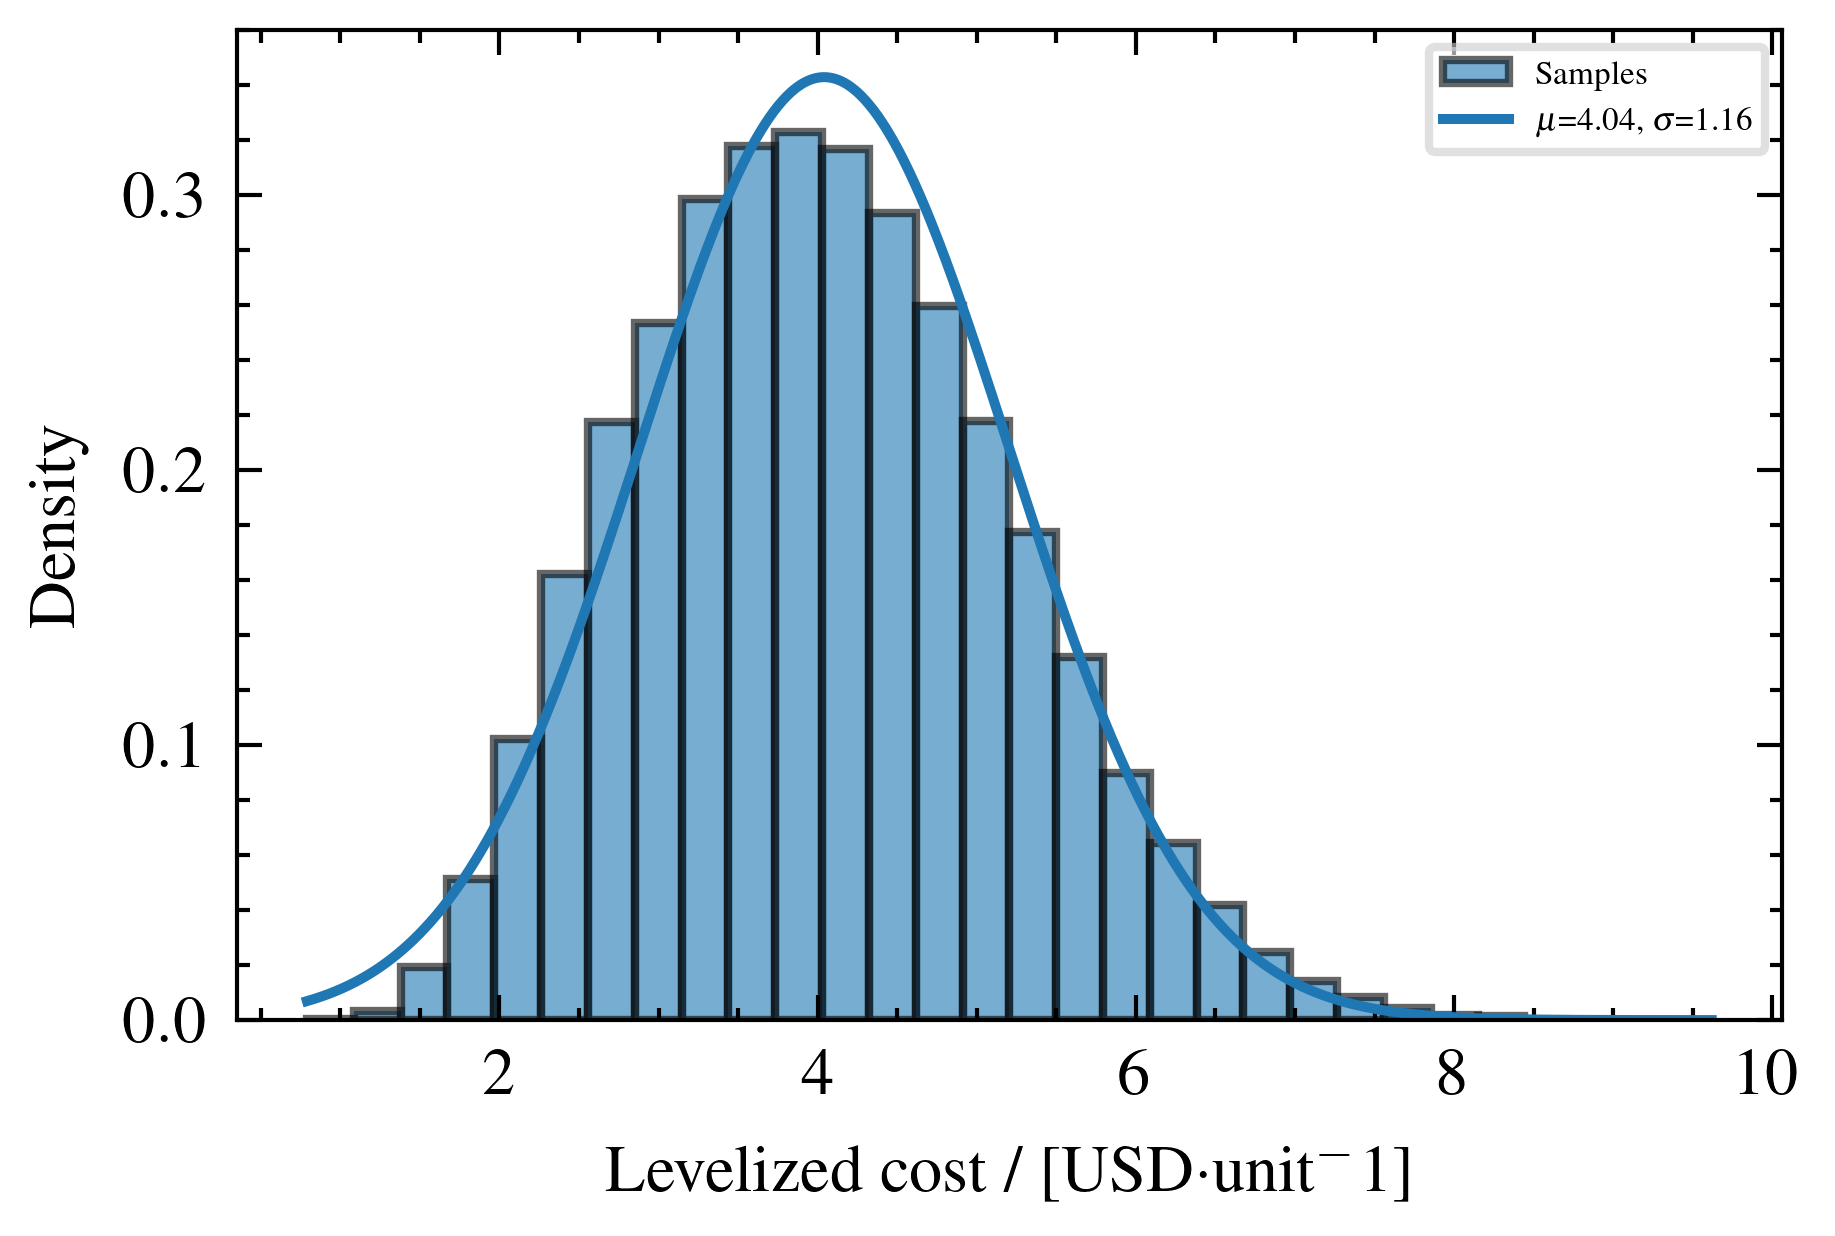

In [9]:
smr_combined_results = load_results(
    filepath="outputs/smr_combined_results/Steam Reforming_analysis_results.json"
)

fig, ax = plot_monte_carlo(smr_combined_results["monte_carlo"])

### **Running The Other Plants and Comparing Results**

Now, the case study can be completed by running the TEA for the other two scenarios, namely methane pyrolysis and water electrolysis, and comparing their Monte Carlo results.

In [10]:
run_tea(equipment_input_path="input_configs/mp_equipment.json",
        plant_input_path="input_configs/mp_plant.json",
        analysis_input_path="input_configs/analysis-2.json",
        output_dir="outputs/mp_tea_results")

run_tea(equipment_input_path="input_configs/we_equipment.json",
        plant_input_path="input_configs/we_plant.json",
        analysis_input_path="input_configs/analysis-2.json",
        output_dir="outputs/we_tea_results")

Monte Carlo: 100%|██████████| 10/10 [00:26<00:00,  2.64s/it]


{'levelized_cost': {'components': [{'CAPEX': 2.506271264678599,
    'OPEX': 4.948592863308699,
    'Side revenue': -0.0}],
  'labels': [['CAPEX', 'OPEX', 'Side revenue']],
  'values': [[2.506271264678599, 4.948592863308699, -0.0]],
  'xlabels': ['Water Electrolysis'],
  'ylabel': 'Levelized cost',
  'currency': 'USD$\\cdot$unit$^{-1}$',
  'pct': False},
 'cash_flow': {'curves': [{'plant': 'Water Electrolysis',
    'years': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
           13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
           26., 27., 28., 29., 30.]),
    'cumulative': array([ 0.00000000e+00, -1.41538514e+08, -3.90259190e+08, -4.92259915e+08,
           -4.83268078e+08, -4.63439193e+08, -4.43610308e+08, -4.23781424e+08,
           -4.03952539e+08, -3.84123654e+08, -3.64294769e+08, -3.44465885e+08,
           -3.24637000e+08, -3.04808115e+08, -2.84979231e+08, -2.65150346e+08,
           -2.45321461e+08, -2.25492576e+08, -2.05663692e

We can use the function `load_results()` to retrieve our Monte Carlo results

In [11]:
mp_mc = load_results(filepath="outputs/mp_tea_results/Methane Pyrolysis_analysis_results.json")["monte_carlo"]
we_mc = load_results(filepath="outputs/we_tea_results/Water Electrolysis_analysis_results.json")["monte_carlo"]

Finally, we plot the Monte Carlo results all in the same figure using `plot_multiple_monte_carlo()` mirroring [Case Study 1](https://github.com/pbtamarona/OpenPyTEA/blob/main/examples/case_study_1.ipynb) (the JSON configuration files carry slightly different assumptions -- e.g. a hydrogen price of $5.5/kg instead of $5/kg -- so the numbers differ slightly from the notebook version):

In [12]:
from openpytea.plotting import plot_multiple_monte_carlo

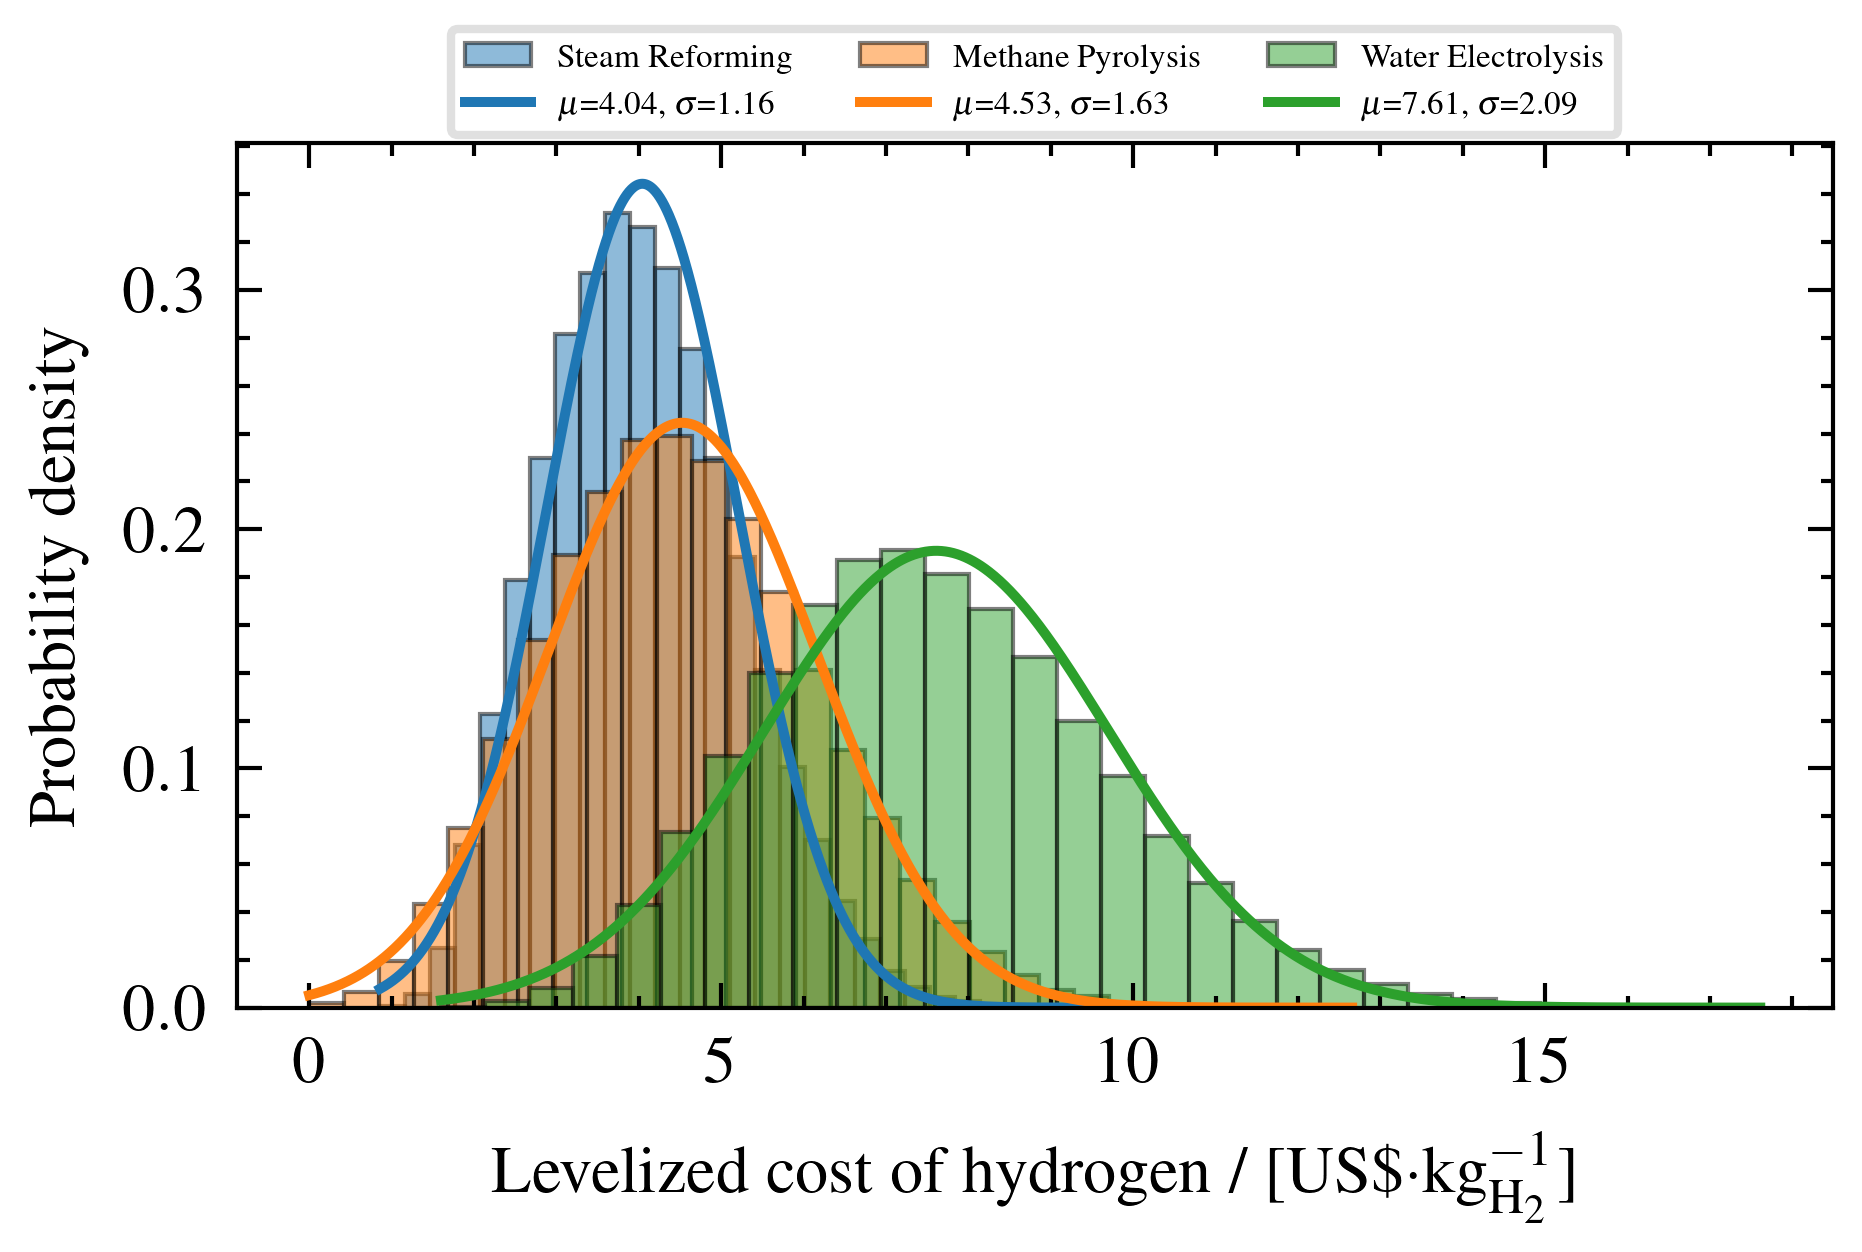

In [16]:
fig, ax = plot_multiple_monte_carlo(data_list=[smr_mc, mp_mc, we_mc], metric="LCOP", bins=30, label=r'Levelized cost of hydrogen / [US\$$\cdot$kg$^{-1}_\mathrm{H_2}$]')